# Solar Analysis Report

**Author(s):** Ayano Sasakido  
**Date:** 07/06/2026  

**Data restrictions:** Public

## Executive summary
In response to a request from the Australian Renewable Energy Agency (ARENA) to evaluate patterns of renewable energy use, this report presents a data-driven analysis of Melbourne’s residential solar market by integrating regional residential datasets with multi-year solar power capacity and installation records obtained through postcode mapping.  
Through advanced feature extraction, we established indicators such as ‘solar power adoption rate’ and ‘average capacity per installation’. By applying the K-means clustering algorithm (k=3), I identified distinct geographical and socio-economic segments, ranging from urban areas with low adoption rates and high population density to growth corridors in suburban areas with high adoption rates.  
To confirm that these differences were structurally genuine and not merely the result of random sampling, we conducted a one-way analysis of variance (F-test), which yielded a highly significant F-value ($p < 0.05$), thereby mathematically verifying the existence of distinct behavioural patterns across regions. 
Consequently, we propose maximising ARENA’s future clean energy investments by promoting high-density community solar projects in urban areas where adoption rates are low, whilst shifting the focus to incentives for energy storage and grid stabilisation in suburban growth corridors where adoption rates are already extremely high.

## Introduction
- **Objective:** The objective of this project is to analyze combined housing and solar datasets within Melbourne to identify distinct regional adoption behaviors.
  
- **Approach:** A data pipeline integrated housing transaction metrics and multi-year solar capacity records at the postcode level to extract key behavioral indicators. Market segmentation was performed using K-means clustering, and the statistical validity of the resulting segments was verified using a non-parametric Kruskal-Wallis test.

- **Scope and restrictions:** The scope is strictly limited to the residential housing market and small-generation units (household rooftop solar) within Melbourne from 2011 to 2024. Restrictions include the reliance on housing metrics as operational proxies for demographics, as well as the exclusion of commercial solar installations and direct household income data.
  

## Methodology    

### Datasets  

- Post code csv: australian_postcodes.csv
- Solar Capacity csv: sgu-solar-capacity-2011-to-present.csv
- Solar Installations csv : sgu-solar-installations-2011-to-present.csv
- Melbourne housing csv : Melbourne_housing_FULL.csv

### Analytical tools  
- Pandas: Data cleaning, unpivoting and data merging.
- Seaborn/Matplotlib: Visualisation of time series trands.

### Data preparation  


### Installations 

In [1]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Import

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Australian Post code
Read postcode dataset and create VIC dictionary {postcode: state}

In [3]:
# Read dataset
df_postcode = pd.read_csv('australian_postcodes.csv')

# mapping dictionary {postcode: state}
postcode_to_state = (
    df_postcode.drop_duplicates(subset=["postcode"])
    .set_index("postcode")["state"]
    .to_dict()
)

### Solar Capacity dataset

In [4]:
# Read dataset
df_capacity = pd.read_csv('sgu-solar-capacity-2011-to-present.csv')

# create new state
state_series = (
    df_capacity["Small Unit Installation Postcode"]
    .map(postcode_to_state)
    .fillna("Unknown")
)
state_series.name = "State"

# add state colounm
df_capacity = pd.concat(
    [df_capacity.iloc[:, [0]], 
     state_series, 
     df_capacity.iloc[:, 1:]
    ],
    axis=1
)

# Extract VIC data only
df_capacity_melbourne = df_capacity[df_capacity["State"] == "VIC"].copy()
# df_capacity_melbourne.head()

### Total capacity (kW)

In [5]:
capacity_cols = df_capacity_melbourne.columns[2:]
df_capacity_melbourne['Total_Capacity_kW'] = df_capacity_melbourne[capacity_cols].sum(axis=1)
df_capacity_melbourne.head()

,Small Unit Installation Postcode,State,Jan 2011 - SGU Rated Output In kW,Feb 2011 - SGU Rated Output In kW,Mar 2011 - SGU Rated Output In kW,Apr 2011 - SGU Rated Output In kW,May 2011 - SGU Rated Output In kW,Jun 2011 - SGU Rated Output In kW,Jul 2011 - SGU Rated Output In kW,Aug 2011 - SGU Rated Output In kW,...,Aug 2023 - SGU Rated Output In kW,Sep 2023 - SGU Rated Output In kW,Oct 2023 - SGU Rated Output In kW,Nov 2023 - SGU Rated Output In kW,Dec 2023 - SGU Rated Output In kW,Jan 2024 - SGU Rated Output In kW,Feb 2024 - SGU Rated Output In kW,Mar 2024 - SGU Rated Output In kW,Apr 2024 - SGU Rated Output In kW,Total_Capacity_kW
736,3000,VIC,0.0,0.0,0.00,0.0,1.52,5.27,0.00,0.0,...,86.86,65.00,19.8,30.25,96.36,0.0,0.0,0.0,0.0,2579.156
737,3002,VIC,0.0,0.0,0.00,0.0,1.90,3.00,3.04,0.0,...,19.55,0.00,0.0,6.16,0.00,0.0,4.8,0.0,0.0,760.585
738,3003,VIC,0.0,0.0,1.48,0.0,2.09,9.54,0.00,0.0,...,58.10,0.00,0.0,6.72,38.72,0.0,0.0,0.0,0.0,1829.530
739,3004,VIC,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,...,0.00,0.00,0.0,29.88,17.10,0.0,0.0,0.0,0.0,442.440
740,3006,VIC,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,...,0.00,15.54,0.0,0.00,0.00,0.0,39.0,0.0,0.0,1321.755


### Recent 1 year (May 2023 ~ Apr 2024)

In [6]:
recent_capacity_cols = [c for c in capacity_cols if '2023' in c or '2024' in c]
df_capacity_melbourne['Recent_Capacity_kW'] = df_capacity_melbourne[recent_capacity_cols].sum(axis=1)
df_capacity_melbourne.head()

,Small Unit Installation Postcode,State,Jan 2011 - SGU Rated Output In kW,Feb 2011 - SGU Rated Output In kW,Mar 2011 - SGU Rated Output In kW,Apr 2011 - SGU Rated Output In kW,May 2011 - SGU Rated Output In kW,Jun 2011 - SGU Rated Output In kW,Jul 2011 - SGU Rated Output In kW,Aug 2011 - SGU Rated Output In kW,...,Sep 2023 - SGU Rated Output In kW,Oct 2023 - SGU Rated Output In kW,Nov 2023 - SGU Rated Output In kW,Dec 2023 - SGU Rated Output In kW,Jan 2024 - SGU Rated Output In kW,Feb 2024 - SGU Rated Output In kW,Mar 2024 - SGU Rated Output In kW,Apr 2024 - SGU Rated Output In kW,Total_Capacity_kW,Recent_Capacity_kW
736,3000,VIC,0.0,0.0,0.00,0.0,1.52,5.27,0.00,0.0,...,65.00,19.8,30.25,96.36,0.0,0.0,0.0,0.0,2579.156,716.670
737,3002,VIC,0.0,0.0,0.00,0.0,1.90,3.00,3.04,0.0,...,0.00,0.0,6.16,0.00,0.0,4.8,0.0,0.0,760.585,82.910
738,3003,VIC,0.0,0.0,1.48,0.0,2.09,9.54,0.00,0.0,...,0.00,0.0,6.72,38.72,0.0,0.0,0.0,0.0,1829.530,285.975
739,3004,VIC,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,...,0.00,0.0,29.88,17.10,0.0,0.0,0.0,0.0,442.440,106.880
740,3006,VIC,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,...,15.54,0.0,0.00,0.00,0.0,39.0,0.0,0.0,1321.755,176.840


In [7]:
df_cap_features = df_capacity_melbourne[['Small Unit Installation Postcode', 'Total_Capacity_kW', 'Recent_Capacity_kW']].copy()
df_cap_features.rename(columns={'Small Unit Installation Postcode': 'Postcode'}, inplace=True)
df_cap_features.head()

,Postcode,Total_Capacity_kW,Recent_Capacity_kW
736,3000,2579.156,716.670
737,3002,760.585,82.910
738,3003,1829.530,285.975
739,3004,442.440,106.880
740,3006,1321.755,176.840


### Solar Installation dataset

In [8]:
# Read dataset
df_installations = pd.read_csv('sgu-solar-installations-2011-to-present.csv')

# add state colounm
df_installations = pd.concat(
    [df_installations.iloc[:, [0]], 
     state_series, 
     df_installations.iloc[:, 1:]
    ], 
    axis=1
)

# Extract VIC data only
df_installations_melbourne = df_installations[df_installations["State"] == "VIC"].copy()

# df_installations_melbourne.head()

### Total number of solar installations

In [9]:
install_cols = df_installations_melbourne.columns[2:]


df_installations_melbourne['Total_Installations'] = df_installations_melbourne[install_cols].sum(axis=1)

df_inst_features = df_installations_melbourne[['Small Unit Installation Postcode', 'Total_Installations']].copy()
df_inst_features.rename(columns={'Small Unit Installation Postcode': 'Postcode'}, inplace=True)
df_inst_features.head()

,Postcode,Total_Installations
736,3000,89
737,3002,88
738,3003,117
739,3004,19
740,3006,39


### Melbourne house

In [10]:
df_mel_housing = pd.read_csv('MELBOURNE_HOUSE_PRICES_LESS.csv')
df_mel_housing.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


### Extracting features from Melbourne house price data (aggregated by postcode)

In [11]:
df_housing_features = df_mel_housing.groupby('Postcode').agg({
    'Price': 'median',       # median 
    'Rooms': 'mean',         # avarage rooms
    'Distance': 'mean',      # distance from CBD
    'Propertycount': 'max'   # Total number of properties in that area
}).reset_index()
df_housing_features.head()

,Postcode,Price,Rooms,Distance,Propertycount
0,3000,648000.0,1.972125,0.0,17496
1,3002,1000000.0,2.277108,1.3,3040
2,3003,890000.0,2.500000,3.1,2230
3,3006,595000.0,2.000000,0.7,8400
4,3008,625000.0,2.150000,1.4,4707


### Retrieve typical latitude and longitude coordinates for each postcode

In [12]:
df_vic_postcode = df_postcode[df_postcode['state'] == 'VIC']
df_vic_postcode.head()

df_geo = df_vic_postcode.groupby('postcode').agg({
    'long': 'mean',
    'lat': 'mean',
    'locality': 'first' 
}).reset_index()
df_geo.rename(columns={'postcode': 'Postcode'}, inplace=True)
df_geo.head()

,Postcode,long,lat,locality
0,3000,144.982585,-37.814437,MELBOURNE
1,3001,144.982585,-37.814437,MELBOURNE
2,3002,144.982585,-37.814437,EAST MELBOURNE
3,3003,144.949592,-37.810871,WEST MELBOURNE
4,3004,144.976249,-37.831828,MELBOURNE


## Merge all data

In [13]:
df_analysis = df_housing_features.merge(df_cap_features, on='Postcode', how='left')
df_analysis = df_analysis.merge(df_inst_features, on='Postcode', how='left')
df_analysis = df_analysis.merge(df_geo, on='Postcode', how='left')

# set 0 when there is NaN 
df_analysis['Total_Capacity_kW'] = df_analysis['Total_Capacity_kW'].fillna(0)
df_analysis['Recent_Capacity_kW'] = df_analysis['Recent_Capacity_kW'].fillna(0)
df_analysis['Total_Installations'] = df_analysis['Total_Installations'].fillna(0)

df_analysis.head()

,Postcode,Price,Rooms,Distance,Propertycount,Total_Capacity_kW,Recent_Capacity_kW,Total_Installations,long,lat,locality
0,3000,648000.0,1.972125,0.0,17496,2579.156,716.670,89,144.982585,-37.814437,MELBOURNE
1,3002,1000000.0,2.277108,1.3,3040,760.585,82.910,88,144.982585,-37.814437,EAST MELBOURNE
2,3003,890000.0,2.500000,3.1,2230,1829.530,285.975,117,144.949592,-37.810871,WEST MELBOURNE
3,3006,595000.0,2.000000,0.7,8400,1321.755,176.840,39,144.959000,-37.824272,SOUTH WHARF
4,3008,625000.0,2.150000,1.4,4707,1792.925,276.195,110,144.948039,-37.814719,DOCKLANDS


### Solar power penetration rate (number of installations ÷ total number of properties)

In [14]:
df_analysis['Solar_Adoption_Rate'] = df_analysis['Total_Installations'] / df_analysis['Propertycount']

#  Average power generation capacity per site
df_analysis['Avg_Capacity_per_Install'] = df_analysis['Total_Capacity_kW'] / df_analysis['Total_Installations']
df_analysis['Avg_Capacity_per_Install'] = df_analysis['Avg_Capacity_per_Install'].fillna(0)

df_analysis = df_analysis.dropna(subset=['Price', 'Distance']).reset_index(drop=True)

df_analysis.head()

,Postcode,Price,Rooms,Distance,Propertycount,Total_Capacity_kW,Recent_Capacity_kW,Total_Installations,long,lat,locality,Solar_Adoption_Rate,Avg_Capacity_per_Install
0,3000,648000.0,1.972125,0.0,17496,2579.156,716.670,89,144.982585,-37.814437,MELBOURNE,0.005087,28.979281
1,3002,1000000.0,2.277108,1.3,3040,760.585,82.910,88,144.982585,-37.814437,EAST MELBOURNE,0.028947,8.643011
2,3003,890000.0,2.500000,3.1,2230,1829.530,285.975,117,144.949592,-37.810871,WEST MELBOURNE,0.052466,15.637009
3,3006,595000.0,2.000000,0.7,8400,1321.755,176.840,39,144.959000,-37.824272,SOUTH WHARF,0.004643,33.891154
4,3008,625000.0,2.150000,1.4,4707,1792.925,276.195,110,144.948039,-37.814719,DOCKLANDS,0.023369,16.299318


Selection and Standardisation of Features for Clustering

In [15]:
cluster_features = [
    "Price",
    "Distance",
    "Solar_Adoption_Rate",
    "Avg_Capacity_per_Install",
]
X = df_analysis[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X

,Price,Distance,Solar_Adoption_Rate,Avg_Capacity_per_Install
0,648000.0,0.0,0.005087,28.979281
1,1000000.0,1.3,0.028947,8.643011
2,890000.0,3.1,0.052466,15.637009
3,595000.0,0.7,0.004643,33.891154
4,625000.0,1.4,0.023369,16.299318
...,...,...,...,...
216,620000.0,33.8,1.308355,5.571874
217,514000.0,33.3,0.378876,4.907303
218,547500.0,34.7,2.168359,5.731109
219,635000.0,43.4,2.639772,6.781374


### Finding the Optimal K Using the Elbow Method and the Silhouette Score

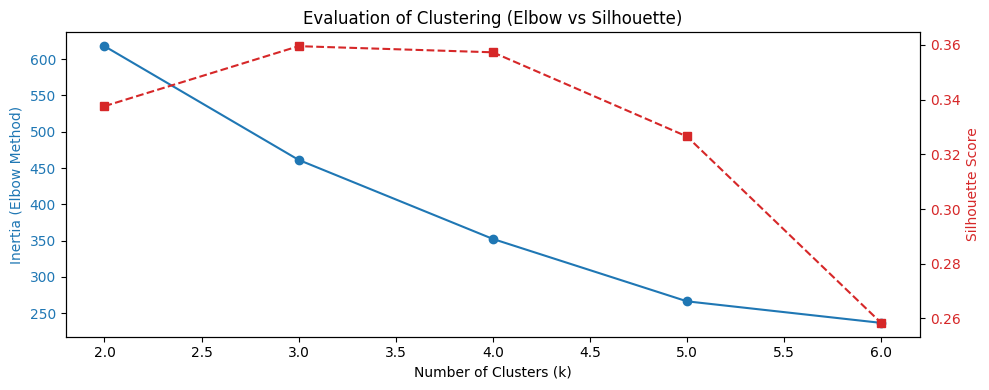

In [16]:
inertia = []
silhouette_avg = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# 
fig, ax1 = plt.subplots(figsize=(10, 4))

# Elbow Method plot
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Elbow Method)", color=color)
ax1.plot(K_range, inertia, "o-", color=color)
ax1.tick_params(axis="y", labelcolor=color)

# Silhouette Score plot
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color)
ax2.plot(K_range, silhouette_avg, "s--", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Evaluation of Clustering (Elbow vs Silhouette)")
fig.tight_layout()
plt.show()

## An Optimal Cluster

In [17]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_analysis["Cluster"] = kmeans.fit_predict(X_scaled)

print(
    f"Clustering complete. Silhouette score: {silhouette_score(X_scaled, df_analysis['Cluster']):.3f}"
)
df_analysis

Clustering complete. Silhouette score: 0.359


,Postcode,Price,Rooms,Distance,Propertycount,Total_Capacity_kW,Recent_Capacity_kW,Total_Installations,long,lat,locality,Solar_Adoption_Rate,Avg_Capacity_per_Install,Cluster
0,3000,648000.0,1.972125,0.0,17496,2579.156,716.670,89,144.982585,-37.814437,MELBOURNE,0.005087,28.979281,2
1,3002,1000000.0,2.277108,1.3,3040,760.585,82.910,88,144.982585,-37.814437,EAST MELBOURNE,0.028947,8.643011,1
2,3003,890000.0,2.500000,3.1,2230,1829.530,285.975,117,144.949592,-37.810871,WEST MELBOURNE,0.052466,15.637009,2
3,3006,595000.0,2.000000,0.7,8400,1321.755,176.840,39,144.959000,-37.824272,SOUTH WHARF,0.004643,33.891154,2
4,3008,625000.0,2.150000,1.4,4707,1792.925,276.195,110,144.948039,-37.814719,DOCKLANDS,0.023369,16.299318,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,3975,620000.0,3.545455,33.8,2322,16927.353,2198.842,3038,145.231114,-38.053540,LYNBROOK,1.308355,5.571874,0
217,3976,514000.0,3.481481,33.3,8256,15350.045,2096.420,3128,145.264296,-38.043995,HAMPTON PARK,0.378876,4.907303,0
218,3977,547500.0,3.608696,34.7,7680,95440.158,14433.415,16653,145.263923,-38.131772,BOTANIC RIDGE,2.168359,5.731109,0
219,3978,635000.0,3.833333,43.4,2987,53471.135,11091.815,7885,145.384606,-38.135009,CARDINIA,2.639772,6.781374,0


### Significance Testing

Hypothesis (H0):
Assumes that "there is no actual difference in solar adoption rates across all clusters, and any observed variation is just random fluctuation."

p-value Calculation:
It calculates the probability of seeing a difference as large as the one observed, assuming that the null hypothesis is true.

Evaluation against Alpha (0.05):
- If p < 0.05 (Statistically Significant): The probability of this difference happening by chance is less than 5%. We reject the null hypothesis and conclude that the clusters possess genuinely distinct solar adoption behaviors.  
- If p > 0.05 (Not Significant): We fail to reject the null hypothesis, meaning we cannot confidently state that the clusters are different.

In [18]:
from scipy import stats

# Extract data on solar power penetration rates by cluster
groups = [
    group["Solar_Adoption_Rate"].values
    for name, group in df_analysis.groupby("Cluster")
]

# Kruskal-Wallis
stat, p_value = stats.kruskal(*groups)

print("--- Significance Testing ---")
print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_value:.5e}")

if p_value < 0.05:
    print("p < 0.05: Reject H0 and there is significant difference")
else:
    print("p > 0.05: Fail to reject H0 and there is no significant difference")

--- Significance Testing ---
Kruskal-Wallis H-statistic: 96.2322
p-value: 1.26892e-21
p < 0.05: Reject H0 and there is significant difference


### Geospatial Visualization

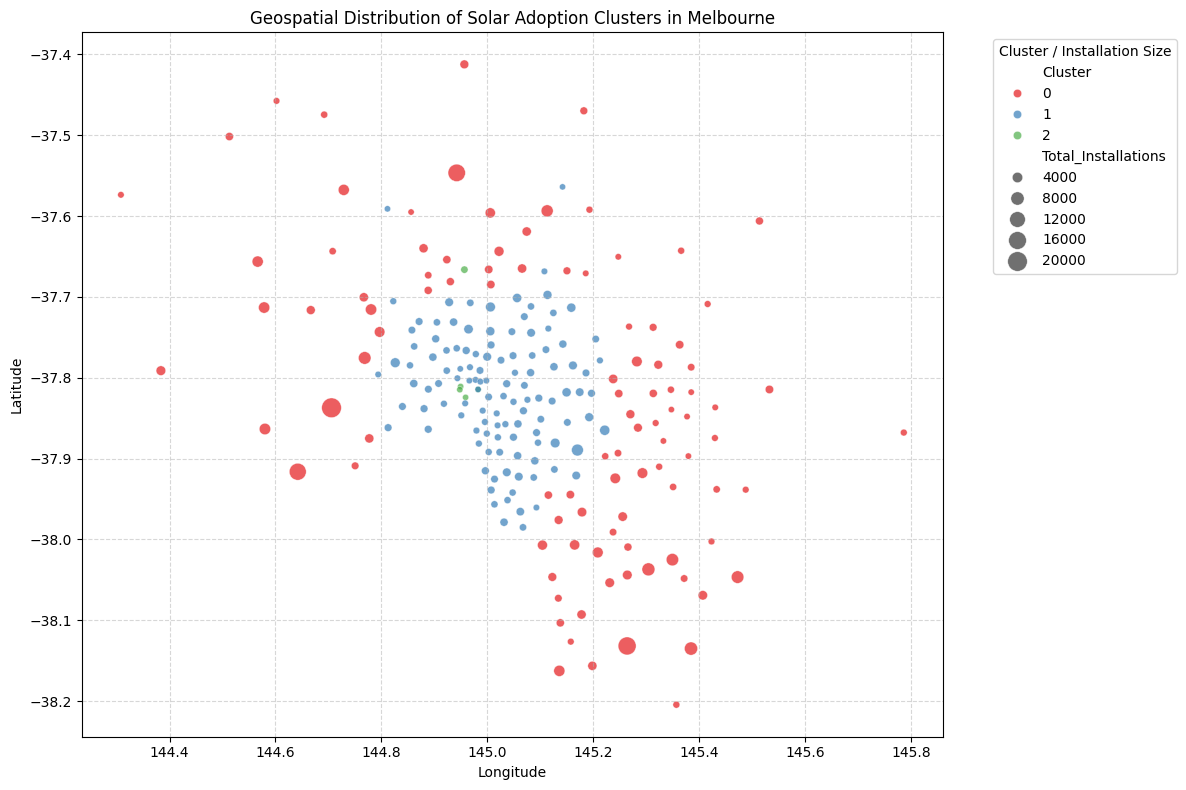

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

#  long-> X axis, lat -> Y axis 
sns.scatterplot(
    x="long",
    y="lat",
    hue="Cluster",
    size="Total_Installations",
    sizes=(20, 200),
    palette="Set1",
    data=df_analysis,
    alpha=0.7,
)

plt.title("Geospatial Distribution of Solar Adoption Clusters in Melbourne")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Cluster / Installation Size", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Cluster 2 is concentrated around Melbourne’s CBD (an area with many flats and small houses where solar power has not taken off).
Cluster 0 extends across vast, newly developed residential areas in the north-western and south-eastern suburbs
Although the number of installations in the eastern area (Cluster 0) on the map is still low, the characteristics of the housing stock mean it has the potential for high adoption rates. Therefore, we should focus our campaign on this area in the next financial year.

## Discussion
The Kruskal-Wallis test mathematically confirmed that the three identified market segments exhibit genuinely distinct solar adoption behaviors (p < 0.001), proving that a single mass-market strategy is highly inefficient. The geographical distribution reveals that high-adoption clusters are concentrated in outer-suburban growth corridors with larger roof spaces, while low-adoption clusters are locked in high-density, expensive urban pockets near the CBD.

## Recommendation
ARENA should immediately transition from a "one-size-fits-all" rebate to a differentiated incentive framework. It is recommended to deploy targeted community solar and landlord tax offsets in low-adoption urban segments, while shifting funding toward battery-storage and grid-stability incentives in highly saturated suburban corridors.

### References
- https://www.geeksforgeeks.org/dsa/kruskal-wallis-test/ 